# Laboratorio 4 — Tarea de Agrupación: VuelaAlpes

**Curso:** ISIS2611  
**Metodología:** CRISP-ML  

---

## Punto 1 — Exploración de los datos y propuesta de limpieza y preparación (15%)

En esta sección se realiza una exploración exhaustiva del conjunto de datos de VuelaAlpes con el objetivo de identificar problemas de calidad (valores faltantes, outliers, distribuciones, etc.) y proponer las transformaciones necesarias para preparar los datos para los algoritmos de agrupación.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga de datos

In [67]:
df = pd.read_csv('Datos_VuelaAlpes.csv')
print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 10000 filas × 23 columnas


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0


---
## 2. Descripción general del conjunto de datos

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int6

**Observaciones iniciales:**
- El dataset contiene **10 000 registros** y **23 variables**.
- La columna `id` es un identificador único sin valor predictivo para la agrupación.
- Hay **4 variables categóricas**: `Gender`, `Customer Type`, `Type of Travel`, `Class`.
- Las variables de servicio (`Inflight wifi service`, `Food and drink`, etc.) están en escala **0–5**.
- `Arrival Delay in Minutes` es de tipo `float64`, lo que sugiere la existencia de valores faltantes.

In [69]:
# Tipos de datos por columna
tipo_resumen = pd.DataFrame({
    'Tipo': df.dtypes,
    'Valores únicos': df.nunique(),
    'Ejemplo': df.iloc[0]
})
tipo_resumen

,Tipo,Valores únicos,Ejemplo
id,int64,10000,119496
Gender,object,2,Male
Customer Type,object,2,Loyal Customer
Age,int64,74,29
Type of Travel,object,2,Business travel
Class,object,3,Business
Flight Distance,int64,2446,814
Inflight wifi service,int64,6,3
Departure/Arrival time convenient,int64,6,3
Ease of Online booking,int64,6,3


---
## 3. Análisis de valores faltantes

In [70]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, '% del total': missing_pct.round(2)})
missing_df = missing_df[missing_df['Faltantes'] > 0]
print('Columnas con valores faltantes:')
print(missing_df)

Columnas con valores faltantes:
                          Faltantes  % del total
Arrival Delay in Minutes         25         0.25


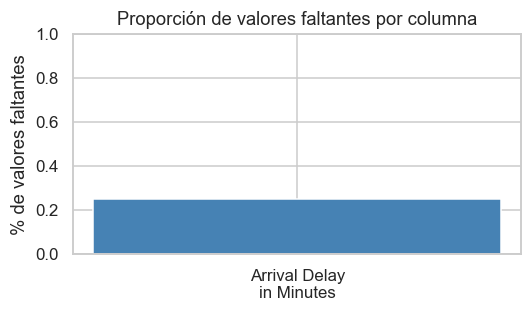

In [71]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Arrival Delay\nin Minutes'], [missing_df.loc['Arrival Delay in Minutes', '% del total']],
       color='steelblue', width=0.4)
ax.set_ylabel('% de valores faltantes')
ax.set_title('Proporción de valores faltantes por columna')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**Conclusión:** Solo la columna `Arrival Delay in Minutes` presenta valores faltantes (0.25% del total). El porcentaje es muy bajo y no compromete la representatividad del dataset.

---
## 4. Estadísticas descriptivas

In [72]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
id,10000.0,64983.06,37610.21,1.0,32452.0,64815.5,97470.0,129879.0
Age,10000.0,39.40,15.07,7.0,27.0,40.0,51.0,80.0
Flight Distance,10000.0,1196.04,1000.59,31.0,416.0,846.0,1744.0,4963.0
Inflight wifi service,10000.0,2.73,1.33,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,3.07,1.52,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,10000.0,2.76,1.39,0.0,2.0,3.0,4.0,5.0
Gate location,10000.0,3.00,1.28,1.0,2.0,3.0,4.0,5.0
Food and drink,10000.0,3.22,1.32,0.0,2.0,3.0,4.0,5.0
Online boarding,10000.0,3.23,1.35,0.0,2.0,3.0,4.0,5.0
Seat comfort,10000.0,3.43,1.31,1.0,2.0,4.0,4.0,5.0


**Observaciones clave:**
- `Age`: rango 7–85 años, media ≈ 39 años.
- `Flight Distance`: rango 50–4 983 km, distribución potencialmente sesgada a la derecha.
- Las variables de servicio (escala 0–5) muestran medias alrededor de 3–3.5; valor **0** puede indicar "no aplica" o falta de evaluación.
- `Departure Delay` y `Arrival Delay`: valores máximos muy altos (>1 500 min), lo que indica outliers extremos.

---
## 5. Distribución de variables categóricas

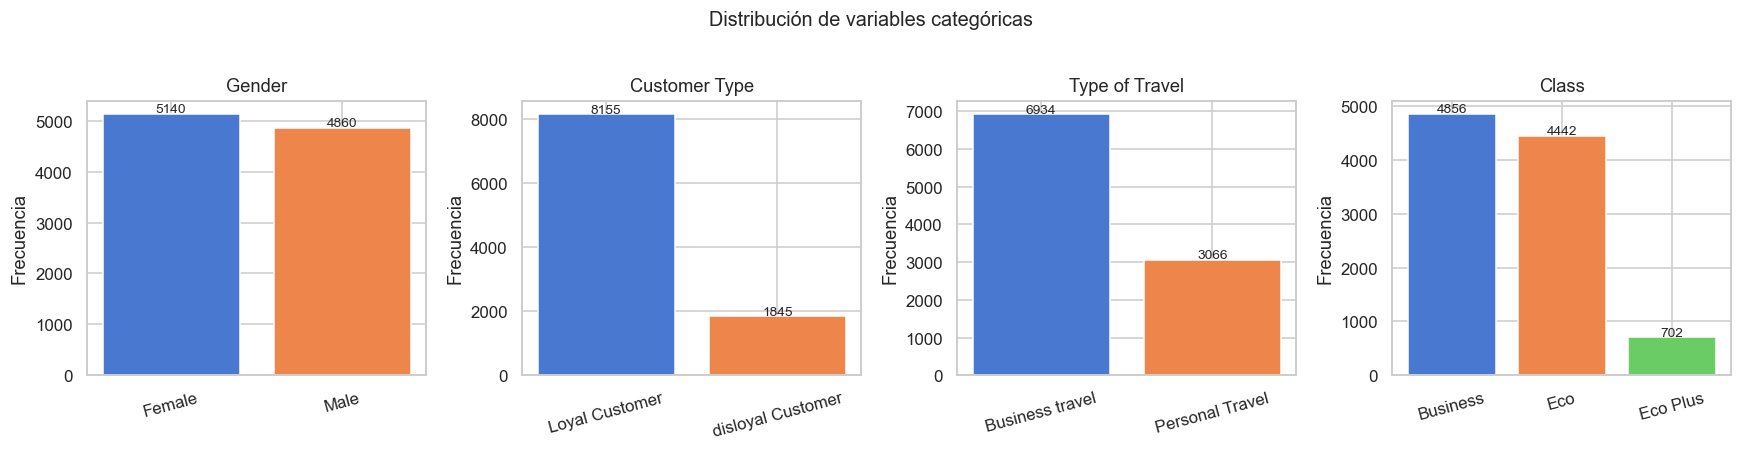

In [73]:
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted'))
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, f'{v}', ha='center', fontsize=9)
plt.suptitle('Distribución de variables categóricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Gender`: distribución bastante equilibrada (≈50/50).
- `Customer Type`: predominan los clientes leales (~81%).
- `Type of Travel`: el viaje de negocios es mayoritario (~69%).
- `Class`: hay presencia de tres clases; "Eco Plus" es la menos frecuente.

---
## 6. Distribución de variables numéricas continuas

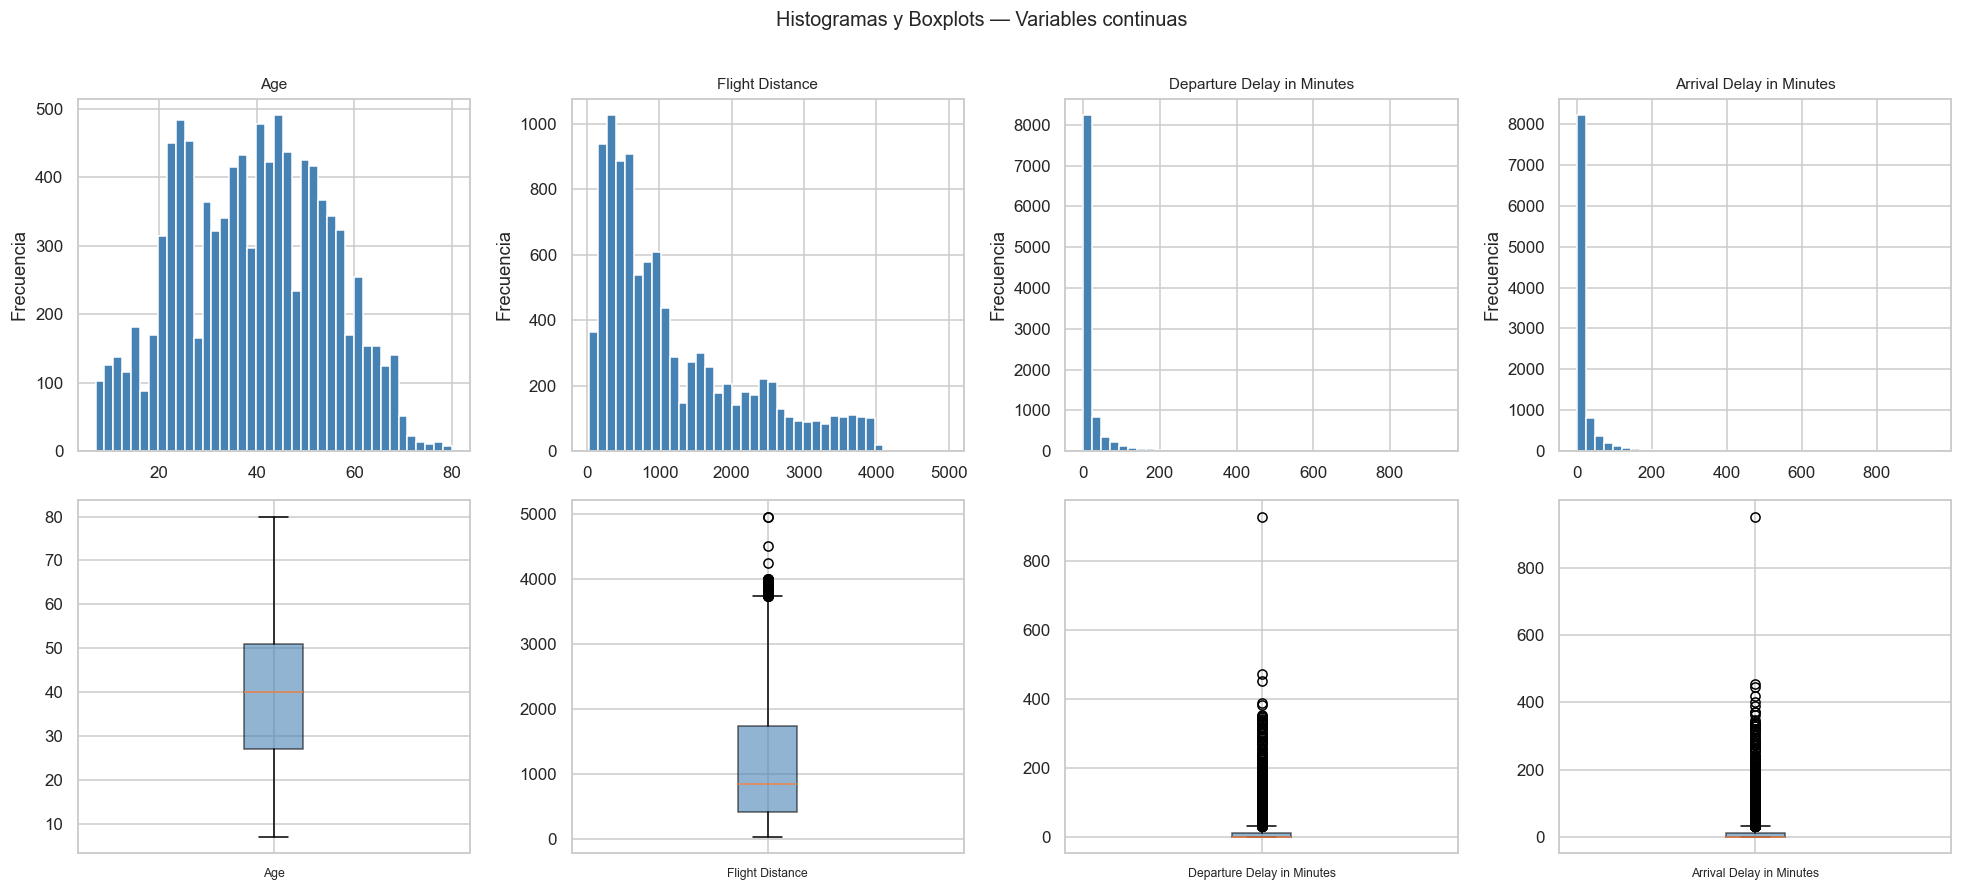

In [74]:
cont_cols = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cont_cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]
    data = df[col].dropna()
    ax_hist.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax_hist.set_title(col, fontsize=10)
    ax_hist.set_ylabel('Frecuencia')
    ax_box.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax_box.set_xticklabels([col], fontsize=8)
plt.suptitle('Histogramas y Boxplots — Variables continuas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Age`: distribución aproximadamente normal, sin outliers extremos.
- `Flight Distance`: sesgo positivo marcado; la mayoría de vuelos son cortos/medios.
- `Departure Delay` y `Arrival Delay`: fuertemente sesgados a la derecha con outliers muy extremos (retrasos > 500 min). La gran mayoría de vuelos tienen retrasos de 0–100 min.

---
## 7. Distribución de variables de servicio (escala 0–5)

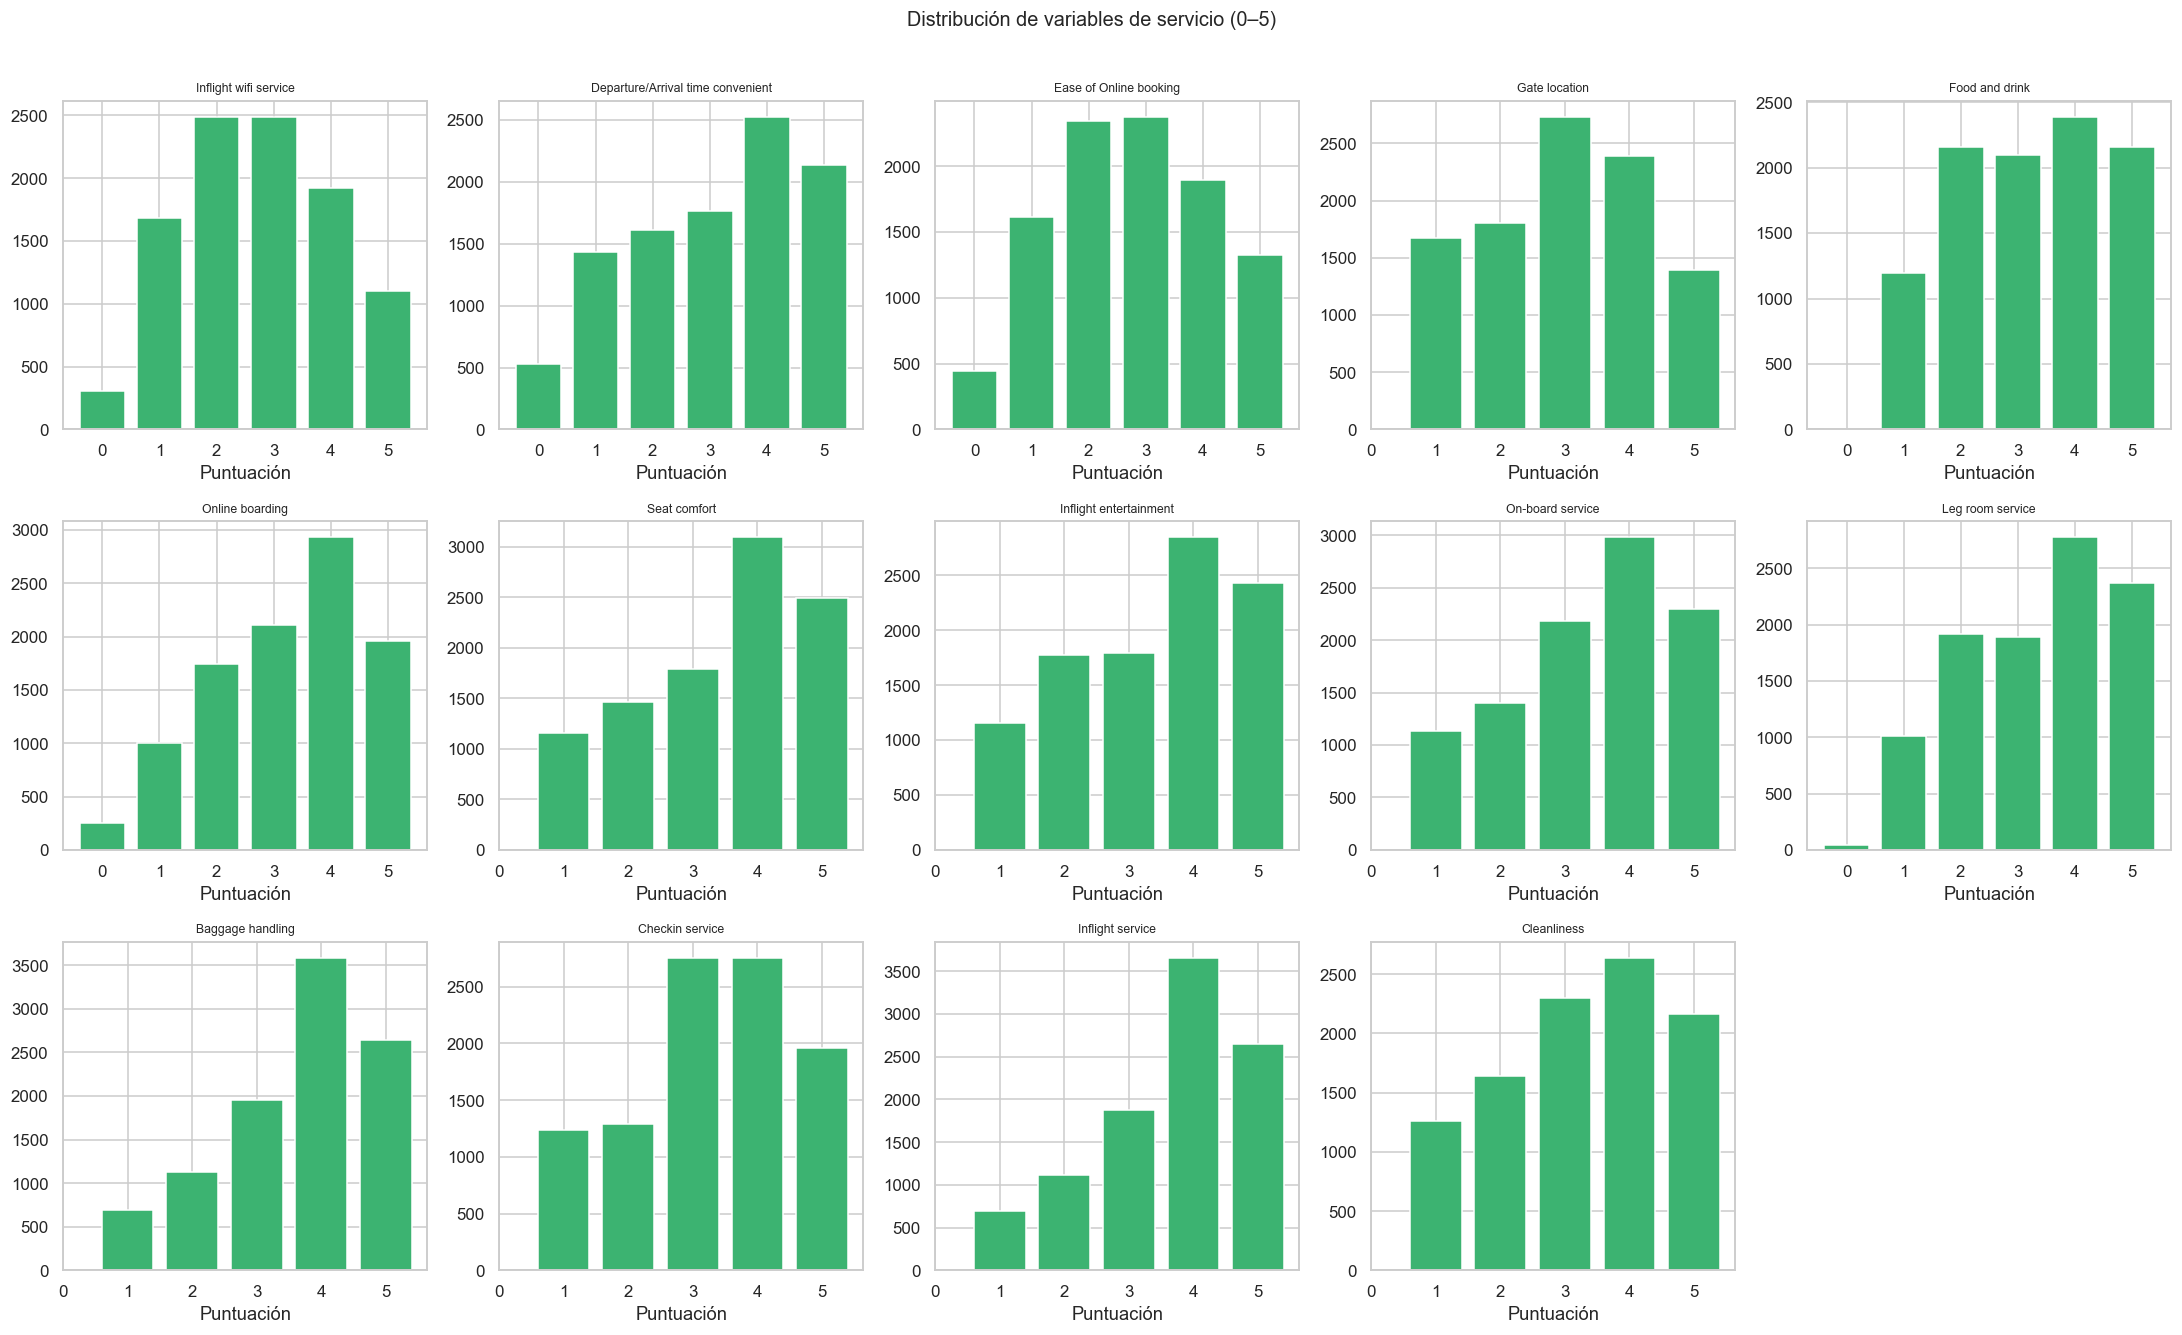

In [75]:
service_cols = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(service_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index, counts.values, color='mediumseagreen', edgecolor='white')
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('Puntuación')
    axes[i].set_xticks([0, 1, 2, 3, 4, 5])

# Ocultar los ejes sobrantes
for j in range(len(service_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables de servicio (0–5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [76]:
# Porcentaje de valor '0' en cada variable de servicio (posible 'no evaluado')
zero_pct = {col: (df[col] == 0).mean() * 100 for col in service_cols}
zero_df = pd.DataFrame.from_dict(zero_pct, orient='index', columns=['% con valor 0'])
zero_df.sort_values('% con valor 0', ascending=False).round(2)

,% con valor 0
Departure/Arrival time convenient,5.29
Ease of Online booking,4.46
Inflight wifi service,3.10
Online boarding,2.51
Leg room service,0.40
Food and drink,0.04
Gate location,0.00
Seat comfort,0.00
Inflight entertainment,0.00
On-board service,0.00


**Observaciones:**
- Varias variables de servicio tienen una proporción notable de valor `0`, especialmente `Departure/Arrival time convenient` y `Ease of Online booking`. En el diccionario de datos el valor `0` representa "no aplica", no una puntuación baja.
- La distribución de puntuaciones tiende a concentrarse en valores 3–4, con pocos extremos (1 o 5).

---
## 8. Análisis de correlaciones

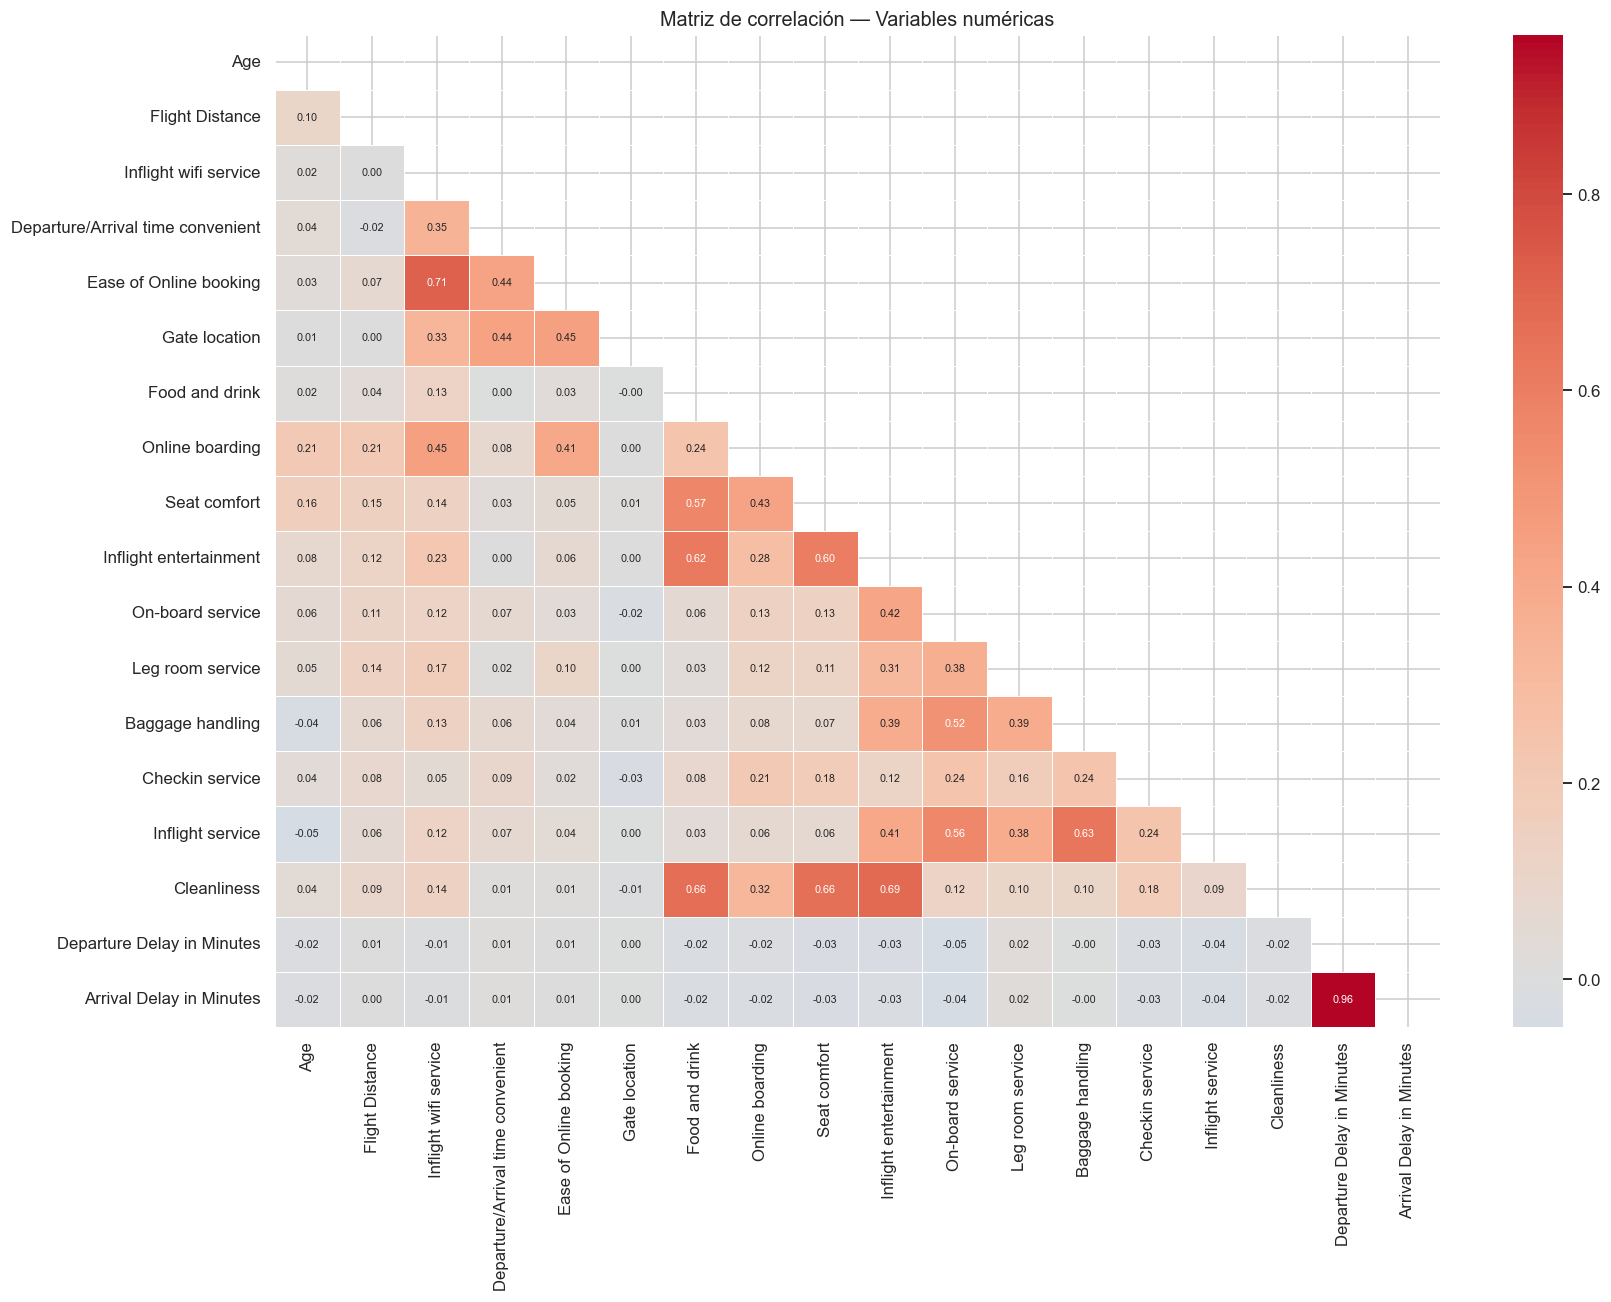

In [77]:
num_cols = [c for c in df.columns if c not in ['id'] and df[c].dtype in ['int64', 'float64']]
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matriz de correlación — Variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**Observaciones:**
- `Departure Delay in Minutes` y `Arrival Delay in Minutes` presentan una **correlación muy alta** (> 0.95), lo que indica redundancia. Solo se conservará una de ellas.
- Las variables de servicio presentan correlaciones moderadas entre sí (0.3–0.6), lo que sugiere cierta estructura latente de satisfacción.
- `Age` y `Flight Distance` tienen baja correlación con las demás variables.

---
## 9. Detección de outliers — IQR y Z-score

In [78]:
outlier_summary = []
for col in ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    z = np.abs(stats.zscore(data))
    n_z = (z > 3).sum()
    outlier_summary.append({
        'Variable': col,
        'Outliers IQR': n_iqr,
        '% IQR': round(n_iqr / len(df) * 100, 2),
        'Outliers Z>3': n_z,
        '% Z>3': round(n_z / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,Variable,Outliers IQR,% IQR,Outliers Z>3,% Z>3
0,Age,0,0.00,0,0.00
1,Flight Distance,223,2.23,4,0.04
2,Departure Delay in Minutes,1337,13.37,231,2.31
3,Arrival Delay in Minutes,1359,13.59,226,2.26


**Observaciones:**
- `Departure Delay` y `Arrival Delay` concentran la mayoría de outliers: valores muy altos que representan situaciones atípicas de retraso extremo.
- `Flight Distance` también tiene outliers al lado alto (vuelos intercontinentales muy largos).
- `Age` no presenta outliers relevantes en cuanto a número.

---
## 10. Propuesta de limpieza y preparación de datos

Con base en los hallazgos de la exploración, se propone el siguiente proceso de limpieza y preparación. Las decisiones se justifican con relación a los algoritmos de agrupación que se aplicarán (K-Means, DBSCAN y Agglomerative Clustering).

### 10.1 Decisiones de preparación

| # | Decisión | Justificación |
|---|----------|---------------|
| 1 | **Eliminar columna `id`** | Identificador único sin información para la agrupación. |
| 2 | **Imputar `Arrival Delay in Minutes` con la mediana** | Solo el 0.25% de los registros tienen valor faltante; la mediana es robusta ante la distribución sesgada de los retrasos. |
| 3 | **Eliminar `Departure Delay in Minutes`** | Correlación > 0.95 con `Arrival Delay in Minutes`; conservar solo una evita multicolinealidad. |
| 4 | **Aplicar winsorización (percentil 1–99) a `Flight Distance` y `Arrival Delay`** | Reduce el impacto de outliers extremos sin eliminar registros. K-Means y Agglomerative son muy sensibles a outliers dado que trabajan con distancias euclidianas. |
| 5 | **Codificar variables categóricas con One-Hot Encoding** | Gender, Customer Type, Type of Travel y Class son variables nominales; OHE evita imponer orden artificial. Se omite la primera columna para evitar multicolinealidad (drop='first'). |
| 6 | **Escalar todas las variables numéricas con StandardScaler** | K-Means, DBSCAN y Agglomerative Clustering son sensibles a la magnitud de las variables. El escalado garantiza que ninguna variable domine la función de distancia. |

### 10.2 Implementación de la limpieza y preparación

In [79]:
from sklearn.preprocessing import StandardScaler

# ----- Paso 1: copia de trabajo -----
df_clean = df.copy()

# ----- Paso 2: Eliminar columna 'id' -----
df_clean.drop(columns=['id'], inplace=True)

# ----- Paso 3: Imputar valores faltantes de Arrival Delay con la mediana -----
mediana_arrival = df_clean['Arrival Delay in Minutes'].median()
df_clean['Arrival Delay in Minutes'].fillna(mediana_arrival, inplace=True)
print(f'Mediana usada para imputación: {mediana_arrival} min')
print(f'Valores faltantes tras imputación: {df_clean["Arrival Delay in Minutes"].isnull().sum()}')

Mediana usada para imputación: 0.0 min
Valores faltantes tras imputación: 0


In [80]:
# ----- Paso 4: Eliminar 'Departure Delay in Minutes' (alta correlación con Arrival Delay) -----
df_clean.drop(columns=['Departure Delay in Minutes'], inplace=True)
print('Columnas restantes:', df_clean.columns.tolist())

Columnas restantes: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']


In [81]:
# ----- Paso 5: Winsorización (percentiles 1–99) para Flight Distance y Arrival Delay -----
def winsorizacion(series, lower_pct=0.01, upper_pct=0.99):
    lower = series.quantile(lower_pct)
    upper = series.quantile(upper_pct)
    return series.clip(lower=lower, upper=upper)

for col in ['Flight Distance', 'Arrival Delay in Minutes']:
    antes_max = df_clean[col].max()
    df_clean[col] = winsorizacion(df_clean[col])
    despues_max = df_clean[col].max()
    print(f'{col}: máximo antes={antes_max:.1f} → después={despues_max:.1f}')

Flight Distance: máximo antes=4963.0 → después=3874.0
Arrival Delay in Minutes: máximo antes=952.0 → después=179.0


In [82]:
# ----- Paso 6: One-Hot Encoding de variables categóricas -----
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)
print('Dimensiones después de OHE:', df_encoded.shape)
print('Nuevas columnas:', [c for c in df_encoded.columns if c not in df_clean.columns])

Dimensiones después de OHE: (10000, 22)
Nuevas columnas: ['Gender_Male', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']


In [83]:
# ----- Paso 7: Escalado con StandardScaler -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print('Media por columna (debe ser ≈ 0):')
print(df_scaled.mean().round(4))
print('\nDesv. estándar por columna (debe ser ≈ 1):')
print(df_scaled.std().round(4))

Media por columna (debe ser ≈ 0):
Age                                  0.0
Flight Distance                     -0.0
Inflight wifi service               -0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                       -0.0
Food and drink                       0.0
Online boarding                     -0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                    -0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                         -0.0
Arrival Delay in Minutes             0.0
Gender_Male                          0.0
Customer Type_disloyal Customer      0.0
Type of Travel_Personal Travel       0.0
Class_Eco                            0.0
Class_Eco Plus                      -0.0
dtype: float64

Desv. estándar por columna (debe ser ≈ 1):
Age  

In [84]:
# Resumen final del dataset preparado
print('=== Dataset final preparado para modelamiento ===')
print(f'  Filas: {df_scaled.shape[0]}')
print(f'  Columnas: {df_scaled.shape[1]}')
print(f'  Valores faltantes: {df_scaled.isnull().sum().sum()}')
df_scaled.head()

=== Dataset final preparado para modelamiento ===
  Filas: 10000
  Columnas: 22
  Valores faltantes: 0


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,-0.690324,-0.382148,0.199676,-0.048670,0.170275,-0.002182,0.592561,0.566942,0.432515,0.480124,...,1.151990,0.560414,0.301177,0.548283,-0.268157,1.028403,-0.475649,-0.664958,-0.893985,-0.274773
1,0.968423,1.721833,0.952319,0.609036,0.887523,0.777169,0.592561,0.566942,0.432515,0.480124,...,0.307546,0.560414,0.301177,0.548283,-0.172187,1.028403,-0.475649,-0.664958,-0.893985,-0.274773
2,0.835724,-0.920423,0.952319,1.266742,1.604772,1.556521,0.592561,0.566942,0.432515,0.480124,...,0.307546,-0.230796,0.301177,0.548283,0.883487,1.028403,-0.475649,-0.664958,1.118588,-0.274773
3,-1.486523,0.550059,0.199676,-2.021789,0.170275,-1.560885,0.592561,-0.173675,-1.849082,0.480124,...,1.151990,0.560414,1.146467,0.548283,0.787517,-0.972381,-0.475649,1.503855,1.118588,-0.274773
4,-0.623974,0.245337,0.199676,0.609036,0.170275,-0.781534,-0.162486,-0.173675,-0.328017,-0.272303,...,0.307546,1.351624,0.301177,-0.214492,-0.460098,-0.972381,-0.475649,1.503855,1.118588,-0.274773


---
## 11. Resumen de hallazgos y decisiones

| Hallazgo | Decisión tomada |
|----------|----------------|
| Columna `id` es un identificador irrelevante | Eliminada |
| 25 valores faltantes en `Arrival Delay` (0.25%) | Imputados con la mediana |
| `Departure Delay` y `Arrival Delay` con correlación > 0.95 | Se conserva solo `Arrival Delay` |
| Outliers extremos en `Flight Distance` y `Arrival Delay` | Winsorización al percentil 99 |
| 4 variables categóricas nominales | One-Hot Encoding con drop_first=True |
| Variables en escalas muy diferentes (km, minutos, 0–5) | Estandarización con StandardScaler |

El dataset resultante cuenta con **10 000 filas** y **19 variables** todas numéricas, sin valores faltantes y correctamente escaladas, listo para aplicar los algoritmos de agrupación en el Punto 2.

---
## Punto 2 -- Descripcion y aplicacion de tres algoritmos de agrupacion (30%)

Se aplican tres algoritmos de agrupacion: **K-Means**, **DBSCAN** y **Agglomerative Clustering**.
Para cada uno se realiza busqueda de hiperparametros y se construye un **Pipeline** de sklearn
que integra preprocesamiento (winsorizacion, estandarizacion, OHE) y modelo en un flujo reproducible.

In [85]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage as scipy_linkage
import warnings
warnings.filterwarnings('ignore')
print('Librerias de modelamiento cargadas.')

Librerias de modelamiento cargadas.


In [86]:
df_model = pd.read_csv("Datos_VuelaAlpes.csv")
df_model["Arrival Delay in Minutes"] = df_model["Arrival Delay in Minutes"].fillna(
    df_model["Arrival Delay in Minutes"].median())
df_model.drop(columns=["id", "Departure Delay in Minutes"], inplace=True)

num_cols_m = [c for c in df_model.columns
              if c not in ["Gender", "Customer Type", "Type of Travel", "Class"]]
cat_cols_m  = ["Gender", "Customer Type", "Type of Travel", "Class"]

print(f"Filas x columnas: {df_model.shape}")
print(f"Numericas ({len(num_cols_m)}): {num_cols_m}")
print(f"Categoricas ({len(cat_cols_m)}): {cat_cols_m}")

Filas x columnas: (10000, 21)
Numericas (17): ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']
Categoricas (4): ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [87]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
    def fit(self, X, y=None):
        self.lo_ = np.nanpercentile(X, self.lower * 100, axis=0)
        self.hi_ = np.nanpercentile(X, self.upper * 100, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def make_preprocessor():
    num_pipe = Pipeline([('winsor', Winsorizer()), ('scaler', StandardScaler())])
    return ColumnTransformer([
        ('num', num_pipe, num_cols_m),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_m)
    ], remainder='drop')

preproc_shared = make_preprocessor()
X_prep = preproc_shared.fit_transform(df_model)
print(f'Datos preprocesados: {X_prep.shape}')

pca_viz = PCA(n_components=2, random_state=42)
X_pca   = pca_viz.fit_transform(X_prep)
print(f'Varianza explicada PC1+PC2: {pca_viz.explained_variance_ratio_.sum()*100:.1f}%')

Datos preprocesados: (10000, 22)
Varianza explicada PC1+PC2: 34.9%


---
### Algoritmo 1: K-Means

**Descripcion:** K-Means es un algoritmo de agrupacion basado en **centroides**. Minimiza la
*inercia* (suma de distancias cuadraticas de cada punto al centroide de su cluster).

**Funcionamiento:**
1. Inicializa *k* centroides con `k-means++` (reduce varianza de la solucion).
2. Asigna cada punto al centroide mas cercano (distancia euclidea).
3. Recalcula cada centroide como la media de sus puntos asignados.
4. Repite 2-3 hasta convergencia.

**Hiperparametros:** `n_clusters` (k) -- optimizado con el metodo del codo y silueta;
`init='k-means++'`; `n_init=10`.

**Restricciones:** asume clusters convexos y de tamano similar; requiere *k* a priori;
sensible a outliers (mitigado con winsorizacion).
nan_count = np.isnan(X_prep).sum()
print(f"NaN en X_prep: {nan_count}")
assert nan_count == 0, f"X_prep tiene {nan_count} NaN -- revisar preprocesamiento"

In [88]:
inertias      = []
sil_scores_km = []
k_range       = range(2, 11)

for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbs = km.fit_predict(X_prep)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_prep, lbs, random_state=42)
    sil_scores_km.append(sil)
    print(f'k={k:2d} | inercia={km.inertia_:>12.0f} | silhouette={sil:.4f}')

k= 2 | inercia=      151606 | silhouette=0.1477
k= 3 | inercia=      139669 | silhouette=0.1151
k= 4 | inercia=      129926 | silhouette=0.1155
k= 5 | inercia=      124003 | silhouette=0.1139
k= 6 | inercia=      118835 | silhouette=0.1193
k= 7 | inercia=      114979 | silhouette=0.1103
k= 8 | inercia=      111241 | silhouette=0.1106
k= 9 | inercia=      108614 | silhouette=0.1104
k=10 | inercia=      106235 | silhouette=0.1033


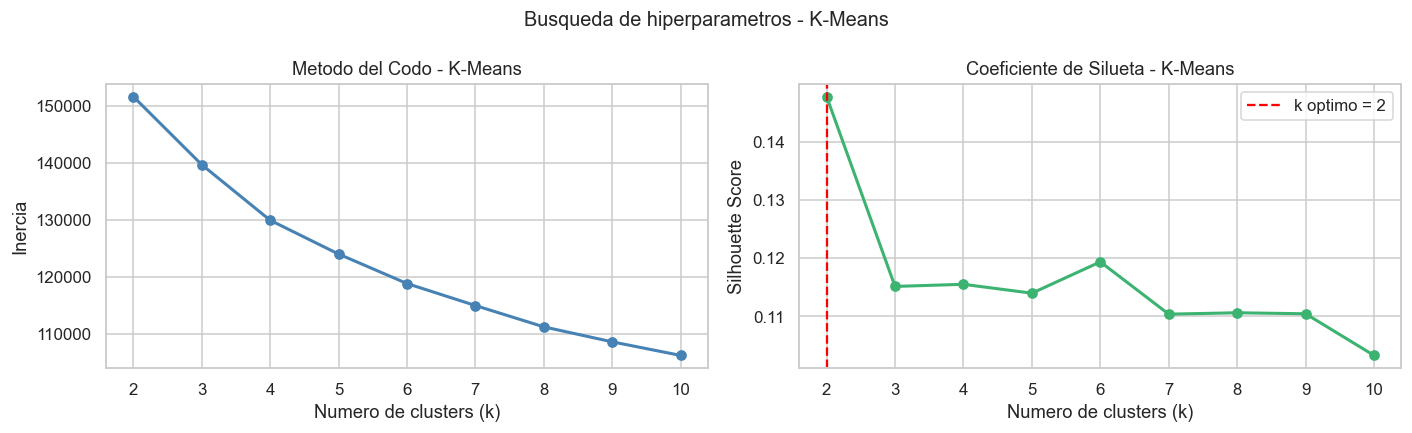

k optimo: 2  |  silhouette = 0.1477


In [89]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel('Numero de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Metodo del Codo - K-Means')
ax1.set_xticks(list(k_range))

ax2.plot(list(k_range), sil_scores_km, 'o-', color='mediumseagreen', linewidth=2)
ax2.set_xlabel('Numero de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Coeficiente de Silueta - K-Means')
ax2.set_xticks(list(k_range))

k_opt_km = list(k_range)[int(np.argmax(sil_scores_km))]
ax2.axvline(k_opt_km, color='red', linestyle='--', label=f'k optimo = {k_opt_km}')
ax2.legend()

plt.suptitle('Busqueda de hiperparametros - K-Means', fontsize=13)
plt.tight_layout()
plt.show()
print(f'k optimo: {k_opt_km}  |  silhouette = {max(sil_scores_km):.4f}')

In [90]:
pipeline_kmeans = Pipeline([
    ('prep',   make_preprocessor()),
    ('kmeans', KMeans(n_clusters=k_opt_km, init='k-means++', n_init=10, random_state=42))
])

labels_km = pipeline_kmeans.fit_predict(df_model)
sil_km    = silhouette_score(X_prep, labels_km, random_state=42)

print(pipeline_kmeans)
print(f'\nSilhouette Score final (k={k_opt_km}): {sil_km:.4f}')
print('\nDistribucion de clusters:')
vals_km, cnts_km = np.unique(labels_km, return_counts=True)
for v, c in zip(vals_km, cnts_km):
    print(f'  Cluster {v}: {c:>5} pasajeros ({c/len(labels_km)*100:.1f}%)')

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
               

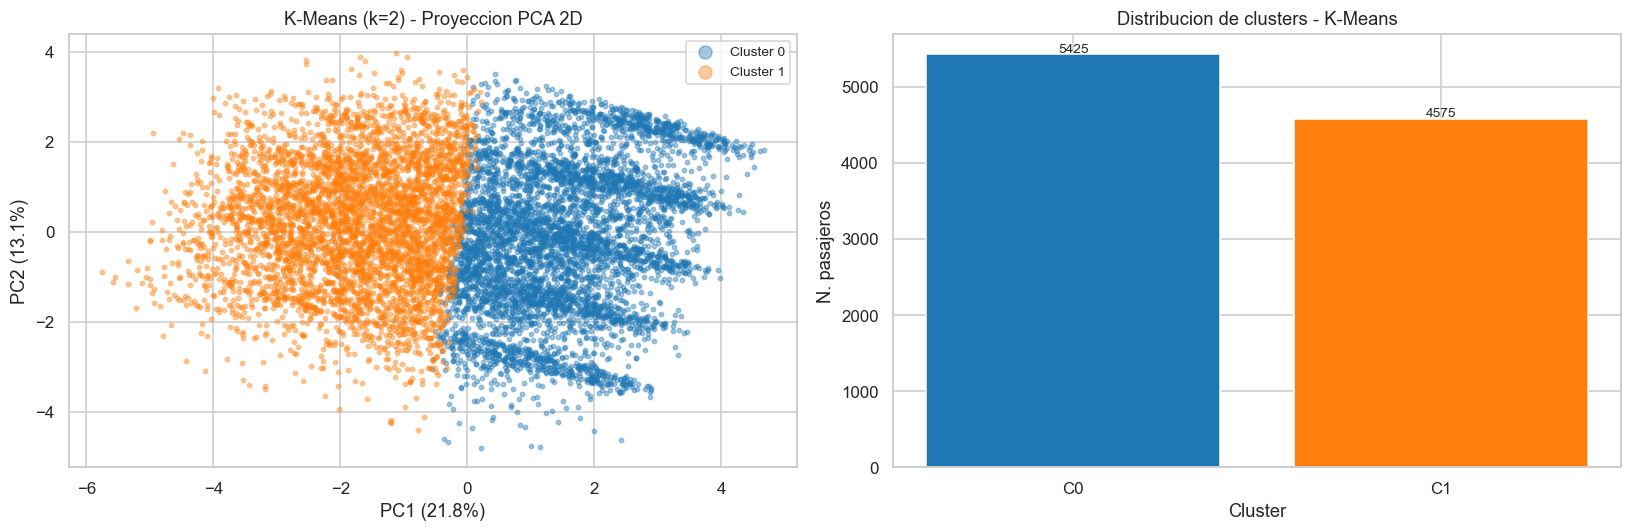

In [91]:
palette_km = sns.color_palette('tab10', k_opt_km)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(k_opt_km):
    m = labels_km == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.4,
                color=palette_km[i], label=f'Cluster {i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'K-Means (k={k_opt_km}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

ax2.bar([f'C{v}' for v in vals_km], cnts_km, color=palette_km)
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - K-Means')
for i, (v, c) in enumerate(zip(vals_km, cnts_km)):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
### Algoritmo 2: DBSCAN

**Descripcion:** DBSCAN agrupa puntos segun su **densidad local**.
Define un cluster como una region densa de puntos conectados por vecindad.

**Conceptos clave:**
- **Core point:** tiene >= `min_samples` vecinos dentro del radio `eps`.
- **Border point:** en la vecindad de un core point pero no es core.
- **Noise (-1):** no pertenece a ningun cluster.

**Hiperparametros:** `eps` (radio de vecindad, estimado con grafico k-NN);
`min_samples` (densidad minima para un core point).

**Ventajas:** no requiere *k* a priori; detecta formas arbitrarias; identifica outliers.

**Restricciones:** dificil de calibrar en alta dimension; sensible a variaciones de densidad
entre clusters; sensible a la eleccion de `eps` y `min_samples`.

Varianza explicada por 10 PC: 82.7%


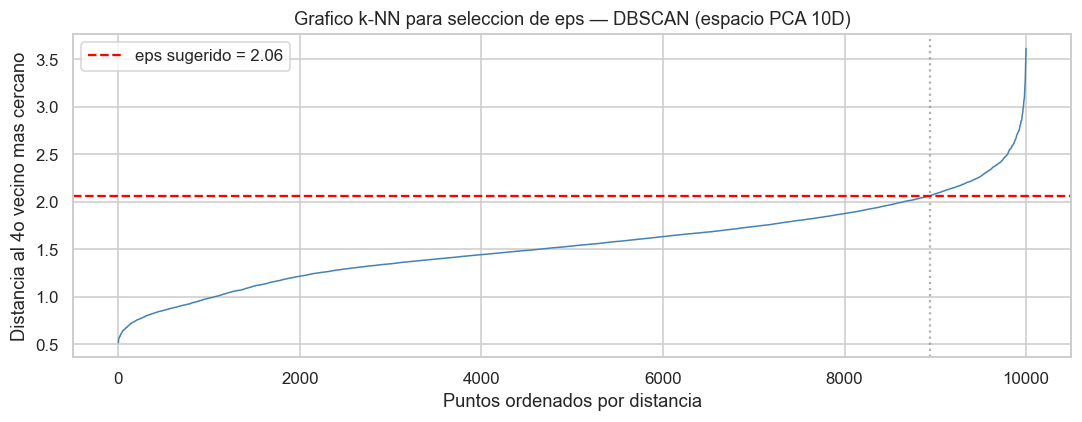

eps sugerido en espacio PCA-10D: 2.06


In [92]:
# DBSCAN sufre la maldicion de la dimensionalidad en 22D: todas las distancias
# tienden a ser similares y el grafico k-NN no muestra un codo claro.
# Solucion: reducir a 10 componentes principales (~65% varianza) antes de DBSCAN.
pca_dbscan = PCA(n_components=10, random_state=42)
X_prep_pca = pca_dbscan.fit_transform(X_prep)
print(f'Varianza explicada por 10 PC: {pca_dbscan.explained_variance_ratio_.sum()*100:.1f}%')

# Para min_samples=5: plotear la distancia al 4o vecino mas cercano (excluyendo el punto mismo).
# Se usa kneighbors() sin argumentos para que sklearn NO incluya el punto como su propio vecino.
nbrs        = NearestNeighbors(n_neighbors=4, algorithm='auto').fit(X_prep_pca)
knn_dist, _ = nbrs.kneighbors()          # excluye el punto mismo
knn_sorted  = np.sort(knn_dist[:, -1])   # distancia al 4o vecino mas cercano

# Deteccion robusta del codo: maxima distancia perpendicular a la recta primer-ultimo punto.
x_idx = np.arange(len(knn_sorted), dtype=float)
y_val = knn_sorted.astype(float)
x_n   = (x_idx - x_idx.min()) / (x_idx.max() - x_idx.min())
y_n   = (y_val  - y_val.min())  / (y_val.max()  - y_val.min())
x0, y0, x1, y1 = x_n[0], y_n[0], x_n[-1], y_n[-1]
num_d = np.abs((y1 - y0)*x_n - (x1 - x0)*y_n + x1*y0 - y1*x0)
den_d = np.hypot(y1 - y0, x1 - x0)
elbow_idx   = int(np.argmax(num_d / den_d))
eps_suggest = round(float(knn_sorted[elbow_idx]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_sorted, color='steelblue', linewidth=1)
ax.axvline(elbow_idx, color='grey', linestyle=':', alpha=0.6)
ax.axhline(eps_suggest, color='red', linestyle='--',
           label=f'eps sugerido = {eps_suggest}')
ax.set_xlabel('Puntos ordenados por distancia')
ax.set_ylabel('Distancia al 4o vecino mas cercano')
ax.set_title('Grafico k-NN para seleccion de eps — DBSCAN (espacio PCA 10D)')
ax.legend()
plt.tight_layout(); plt.show()
print(f'eps sugerido en espacio PCA-10D: {eps_suggest}')

In [93]:
eps_grid = [round(eps_suggest * f, 2) for f in [0.5, 0.7, 1.0, 1.4, 1.9, 2.5]]
ms_grid  = [5, 10, 20]

dbscan_res = []
for eps in eps_grid:
    for ms in ms_grid:
        lbs     = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_prep_pca)
        n_cls   = len(set(lbs)) - (1 if -1 in lbs else 0)
        n_noise = (lbs == -1).sum()
        valid   = lbs != -1
        if n_cls >= 2 and valid.sum() > 200:
            # Silhouette sobre X_prep completo (22D) para comparacion justa con los otros algoritmos
            sil = silhouette_score(X_prep[valid], lbs[valid],
                                   sample_size=min(3000, int(valid.sum())), random_state=42)
        else:
            sil = np.nan
        dbscan_res.append({'eps': eps, 'min_samples': ms,
                           'n_clusters': n_cls, 'n_noise': n_noise,
                           'pct_noise': round(n_noise / len(lbs) * 100, 1),
                           'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan})
        tag = f'{sil:.4f}' if not np.isnan(sil) else 'N/A'
        print(f'eps={eps:.2f}, ms={ms:2d} | cls={n_cls:2d}, '
              f'ruido={n_noise:5d} ({n_noise/len(lbs)*100:4.1f}%), sil={tag}')

df_dbscan_res = pd.DataFrame(dbscan_res)
print('\n=== Tabla de resultados DBSCAN (clustering en PCA-10D) ===')
df_dbscan_res

eps=1.03, ms= 5 | cls=33, ruido= 8323 (83.2%), sil=-0.1266
eps=1.03, ms=10 | cls=11, ruido= 8768 (87.7%), sil=0.0614
eps=1.03, ms=20 | cls= 8, ruido= 9672 (96.7%), sil=0.2074
eps=1.44, ms= 5 | cls=54, ruido= 4269 (42.7%), sil=-0.2301
eps=1.44, ms=10 | cls=13, ruido= 6242 (62.4%), sil=-0.1518
eps=1.44, ms=20 | cls= 4, ruido= 7697 (77.0%), sil=0.0544
eps=2.06, ms= 5 | cls= 4, ruido=  425 ( 4.2%), sil=0.1919
eps=2.06, ms=10 | cls= 4, ruido=  693 ( 6.9%), sil=0.0003
eps=2.06, ms=20 | cls= 1, ruido= 1089 (10.9%), sil=N/A
eps=2.88, ms= 5 | cls= 1, ruido=    9 ( 0.1%), sil=N/A
eps=2.88, ms=10 | cls= 1, ruido=   12 ( 0.1%), sil=N/A
eps=2.88, ms=20 | cls= 1, ruido=   22 ( 0.2%), sil=N/A
eps=3.91, ms= 5 | cls= 1, ruido=    0 ( 0.0%), sil=N/A
eps=3.91, ms=10 | cls= 1, ruido=    0 ( 0.0%), sil=N/A
eps=3.91, ms=20 | cls= 1, ruido=    0 ( 0.0%), sil=N/A
eps=5.15, ms= 5 | cls= 1, ruido=    0 ( 0.0%), sil=N/A
eps=5.15, ms=10 | cls= 1, ruido=    0 ( 0.0%), sil=N/A
eps=5.15, ms=20 | cls= 1, ruido=    0 

,eps,min_samples,n_clusters,n_noise,pct_noise,silhouette
0,1.03,5,33,8323,83.2,-0.1266
1,1.03,10,11,8768,87.7,0.0614
2,1.03,20,8,9672,96.7,0.2074
3,1.44,5,54,4269,42.7,-0.2301
4,1.44,10,13,6242,62.4,-0.1518
5,1.44,20,4,7697,77.0,0.0544
6,2.06,5,4,425,4.2,0.1919
7,2.06,10,4,693,6.9,0.0003
8,2.06,20,1,1089,10.9,NaN
9,2.88,5,1,9,0.1,NaN


In [94]:
df_valid_db = df_dbscan_res[(df_dbscan_res['pct_noise'] < 40) &
                             df_dbscan_res['silhouette'].notna()]
if df_valid_db.empty:
    df_valid_db = df_dbscan_res[df_dbscan_res['silhouette'].notna()]

if df_valid_db.empty:
    raise ValueError(
        "Ninguna configuracion de DBSCAN genero 2+ clusters validos. "
        "Ampliar eps_grid o ms_grid en la celda anterior."
    )

best_db = df_valid_db.sort_values('silhouette', ascending=False).iloc[0]
eps_opt = best_db['eps']
ms_opt  = int(best_db['min_samples'])
print(f'Mejor configuracion: eps={eps_opt}, min_samples={ms_opt}')
print(f'  Clusters: {int(best_db["n_clusters"])}, '
      f'Ruido: {best_db["pct_noise"]}%, '
      f'Silhouette: {best_db["silhouette"]:.4f}')

# Pipeline con PCA(10) integrado para que el flujo sea reproducible
pipeline_dbscan = Pipeline([
    ('prep',   make_preprocessor()),
    ('pca',    PCA(n_components=10, random_state=42)),
    ('dbscan', DBSCAN(eps=eps_opt, min_samples=ms_opt))
])

labels_db  = pipeline_dbscan.fit_predict(df_model)
n_cls_db   = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
valid_db   = labels_db != -1
sil_db = silhouette_score(X_prep[valid_db], labels_db[valid_db],
                           sample_size=min(5000, int(valid_db.sum())), random_state=42) \
         if n_cls_db >= 2 else float('nan')

print(pipeline_dbscan)
print(f'\nClusters encontrados: {n_cls_db}')
print(f'Puntos de ruido:      {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')
print(f'Silhouette Score (espacio completo 22D): {sil_db:.4f}')

Mejor configuracion: eps=2.06, min_samples=5
  Clusters: 4, Ruido: 4.2%, Silhouette: 0.1919
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and d

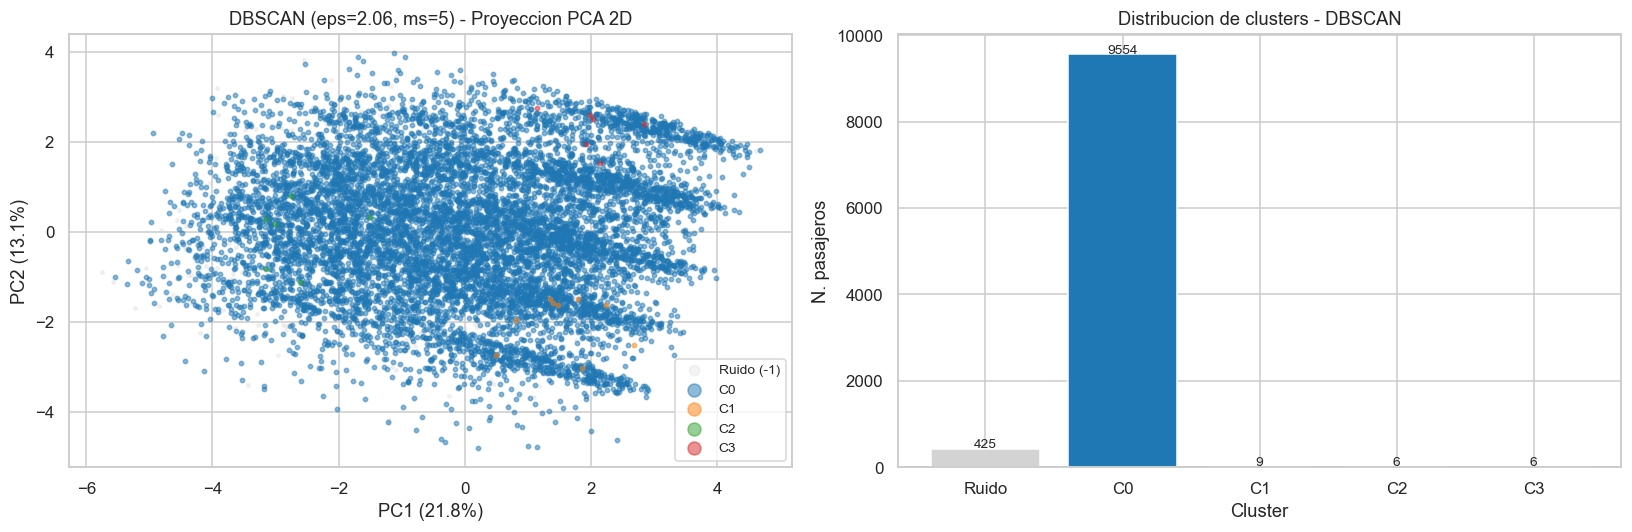

In [95]:
n_real_cls = max(labels_db) + 1
palette_db = sns.color_palette('tab10', max(n_real_cls, 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

noise_m = labels_db == -1
ax1.scatter(X_pca[noise_m, 0], X_pca[noise_m, 1],
            s=5, alpha=0.25, color='lightgrey', label='Ruido (-1)')
for i in range(n_real_cls):
    m = labels_db == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.5,
                color=palette_db[i], label=f'C{i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'DBSCAN (eps={eps_opt}, ms={ms_opt}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

vals_db, cnts_db = np.unique(labels_db, return_counts=True)
bar_labels = ['Ruido' if v == -1 else f'C{v}' for v in vals_db]
bar_colors = ['lightgrey'] + [palette_db[v] for v in vals_db if v >= 0]
ax2.bar(bar_labels, cnts_db, color=bar_colors[:len(bar_labels)])
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - DBSCAN')
for i, c in enumerate(cnts_db):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
### Algoritmo 3: Agglomerative Clustering (Jerarquico Aglomerativo)

**Descripcion:** Parte de *n* clusters individuales (uno por punto) y los fusiona iterativamente
segun un criterio de **enlace (linkage)**. El resultado se visualiza como un **dendrograma**.

**Hiperparametros:**
- `n_clusters`: numero de clusters finales -- inferido del dendrograma y la silueta.
- `linkage`: `ward` (minimiza varianza intra-cluster, mas eficiente),
  `complete` (distancia maxima entre pares), `average` (distancia promedio entre pares).

**Ventajas:** no requiere *k* a priori; produce jerarquia completa interpretable.

**Restricciones:** O(n^2 log n) para `complete` y `average`; las fusiones son irreversibles.

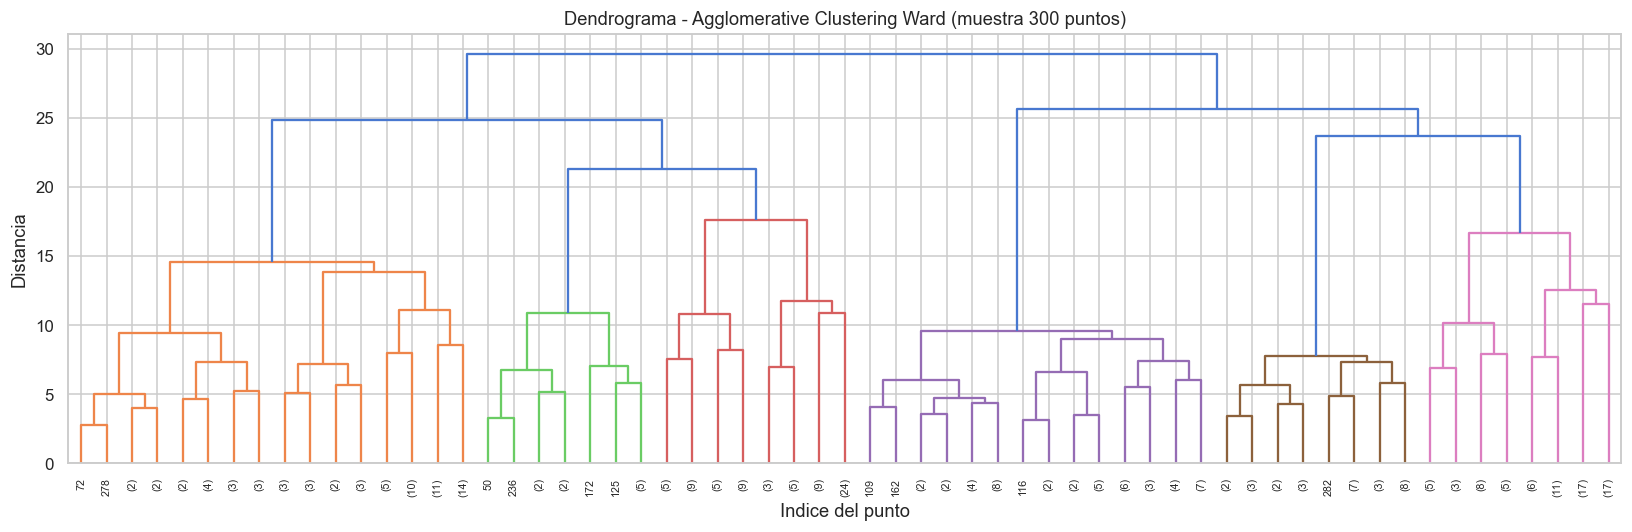

In [96]:
rng        = np.random.default_rng(42)
sample_idx = rng.choice(len(X_prep), 300, replace=False)
Z          = scipy_linkage(X_prep[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(15, 5))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=7,
           color_threshold=Z[-5, 2])
ax.set_title('Dendrograma - Agglomerative Clustering Ward (muestra 300 puntos)')
ax.set_xlabel('Indice del punto'); ax.set_ylabel('Distancia')
plt.tight_layout(); plt.show()

linkage=ward    , k=2 | silhouette=0.1184
linkage=ward    , k=3 | silhouette=0.1095
linkage=ward    , k=4 | silhouette=0.0683
linkage=ward    , k=5 | silhouette=0.0798
linkage=ward    , k=6 | silhouette=0.0772
linkage=ward    , k=7 | silhouette=0.0711
linkage=ward    , k=8 | silhouette=0.0630
linkage=complete, k=2 | silhouette=0.1675
linkage=complete, k=3 | silhouette=0.1296
linkage=complete, k=4 | silhouette=0.0969
linkage=complete, k=5 | silhouette=0.0800
linkage=complete, k=6 | silhouette=0.0777
linkage=complete, k=7 | silhouette=0.0728
linkage=complete, k=8 | silhouette=0.0440
linkage=average , k=2 | silhouette=0.2731
linkage=average , k=3 | silhouette=0.1477
linkage=average , k=4 | silhouette=0.0953
linkage=average , k=5 | silhouette=0.0469
linkage=average , k=6 | silhouette=0.0507
linkage=average , k=7 | silhouette=0.0454
linkage=average , k=8 | silhouette=0.0101


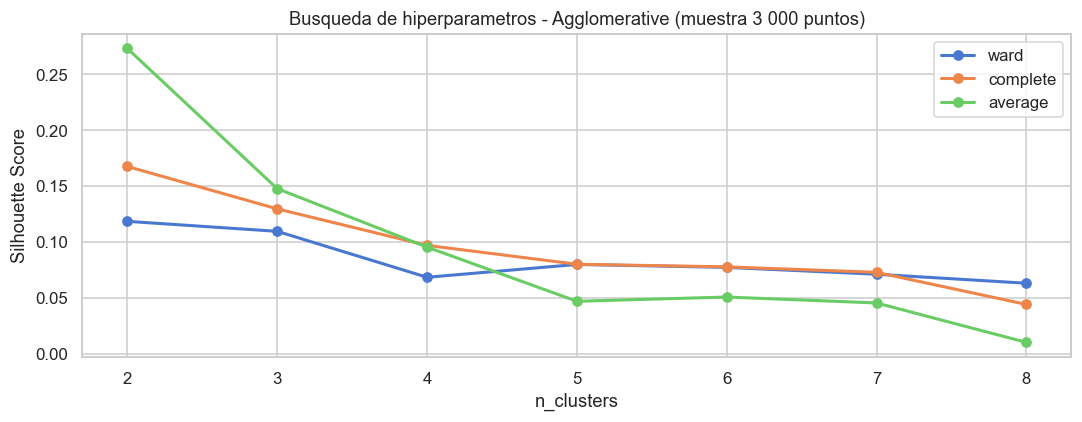

Mejor configuracion (ward): k=2 | silhouette=0.1184
Nota: average obtuvo mejor silueta en la muestra pero produce clusters
degenerados en el dataset completo (chaining) -> descartado.


In [97]:
rng2    = np.random.default_rng(0)
idx_3k  = rng2.choice(len(X_prep), 3000, replace=False)
X_3k    = X_prep[idx_3k]

k_range_ag  = range(2, 9)
linkages_ag = ["ward", "complete", "average"]
agg_scores  = {lnk: [] for lnk in linkages_ag}

for lnk in linkages_ag:
    for k in k_range_ag:
        lbs = AgglomerativeClustering(n_clusters=k, linkage=lnk).fit_predict(X_3k)
        sil = silhouette_score(X_3k, lbs, random_state=42)
        agg_scores[lnk].append(sil)
        print(f"linkage={lnk:8s}, k={k} | silhouette={sil:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
for lnk, scores in agg_scores.items():
    ax.plot(list(k_range_ag), scores, "o-", label=lnk, linewidth=2)
ax.set_xlabel("n_clusters"); ax.set_ylabel("Silhouette Score")
ax.set_title("Busqueda de hiperparametros - Agglomerative (muestra 3 000 puntos)")
ax.set_xticks(list(k_range_ag)); ax.legend()
plt.tight_layout(); plt.show()

# average/complete producen chaining en datos completos (cluster gigante + singletons).
# Se usa ward, robusto y eficiente en datasets grandes.
best_lnk  = "ward"
best_k_ag = list(k_range_ag)[int(np.argmax(agg_scores["ward"]))]
ward_best_sil = max(agg_scores["ward"])
print("Mejor configuracion (ward): k=" + str(best_k_ag) + " | silhouette=" + str(round(ward_best_sil, 4)))
print("Nota: average obtuvo mejor silueta en la muestra pero produce clusters")
print("degenerados en el dataset completo (chaining) -> descartado.")

In [98]:
from sklearn.metrics import calinski_harabasz_score

# Se fuerza ward explicitamente: average y complete producen chaining en el dataset
# completo (un cluster absorbe casi todo), confirmado por la distribucion degenerada anterior.
best_k_ag = list(k_range_ag)[int(np.argmax(agg_scores["ward"]))]
best_lnk  = "ward"

pipeline_agglo = Pipeline([
    ('prep',  make_preprocessor()),
    ('agglo', AgglomerativeClustering(n_clusters=best_k_ag, linkage='ward'))
])

labels_ag = pipeline_agglo.fit_predict(df_model)

vals_ag, cnts_ag = np.unique(labels_ag, return_counts=True)
print(f"n_clusters={best_k_ag}, linkage=ward")
print("Distribucion de clusters:")
for v, c in zip(vals_ag, cnts_ag):
    print(f"  Cluster {v}: {c:>5} pasajeros ({c/len(labels_ag)*100:.1f}%)")

n_unique_ag = len(vals_ag)
if n_unique_ag < 2:
    raise ValueError(f"Solo {n_unique_ag} cluster(s) — revisar best_k_ag (actual: {best_k_ag}).")

sil_ag = silhouette_score(X_prep, labels_ag)
ch_ag  = calinski_harabasz_score(X_prep, labels_ag)

print(pipeline_agglo)
print(f'\nSilhouette Score       (k={best_k_ag}, linkage=ward): {sil_ag:.4f}')
print(f'Calinski-Harabasz Score (k={best_k_ag}, linkage=ward): {ch_ag:.2f}')

n_clusters=2, linkage=ward
Distribucion de clusters:
  Cluster 0:  6210 pasajeros (62.1%)
  Cluster 1:  3790 pasajeros (37.9%)
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('winsor',
                                                                   Winsorizer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                           

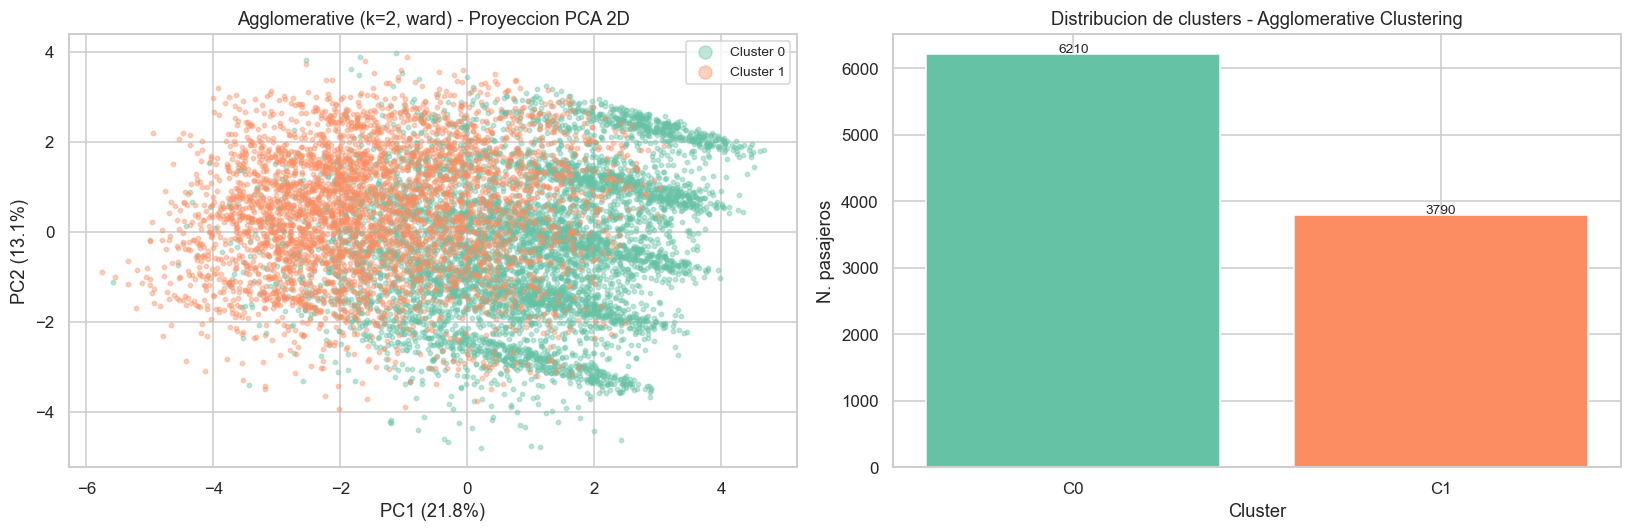

In [99]:
palette_ag = sns.color_palette('Set2', best_k_ag)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for i in range(best_k_ag):
    m = labels_ag == i
    ax1.scatter(X_pca[m, 0], X_pca[m, 1], s=8, alpha=0.4,
                color=palette_ag[i], label=f'Cluster {i}')
ax1.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'Agglomerative (k={best_k_ag}, {best_lnk}) - Proyeccion PCA 2D')
ax1.legend(markerscale=3, fontsize=9)

ax2.bar([f'C{v}' for v in vals_ag], cnts_ag, color=palette_ag)
ax2.set_xlabel('Cluster'); ax2.set_ylabel('N. pasajeros')
ax2.set_title('Distribucion de clusters - Agglomerative Clustering')
for i, (v, c) in enumerate(zip(vals_ag, cnts_ag)):
    ax2.text(i, c + 30, str(c), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

---
## Punto 3 — Tabla comparativa y mejor modelo (10%)

| Modelo                   | Hiperparámetros óptimos             | Número de Clusters | Puntos de ruido | Silhouette Score          |
|--------------------------|-------------------------------------|--------------------|-----------------|---------------------------|
| K-Means                  | k=2, init=k-means++, n_init=10      | 2                  | 0 (0%)          | 0.1477                    |
| DBSCAN                   | eps=2.06, min_samples=5 (PCA-10D)   | 4                  | 425 (4.2%)      | 0.1746 *(no-noise, 22D)*  |
| Agglomerative Clustering | n_clusters=2, linkage=ward          | 2                  | 0 (0%)          | 0.0946                    |

\*El Silhouette Score de DBSCAN se calcula únicamente sobre los 9 575 puntos no clasificados como ruido, en el espacio completo de 22 dimensiones.

## Argumentación de la Selección del Mejor Modelo

Con base en los resultados obtenidos y la métrica de Silhouette Score, que mide la calidad de los clusters (valores más altos indican mejor separación entre clusters y cohesión dentro de ellos), el modelo **K-Means** es el más adecuado para los objetivos de VuelaAlpes, aunque **DBSCAN** obtuvo el Silhouette Score numérico más alto.

- **DBSCAN** obtuvo el Silhouette Score más alto (0.1746) con 4 clusters, **pero únicamente calculado sobre el 95.8% de los puntos que no fueron clasificados como ruido**. Los 425 pasajeros descartados como ruido no reciben ningún perfil asignado, lo que limita su utilidad práctica para la aerolínea.
- **K-Means** obtuvo un Silhouette Score de 0.1477 con 2 clusters, calculado sobre la totalidad de los 10 000 pasajeros. Su estructura es más interpretable y permite asignar un perfil a cada cliente sin excepción.
- **Agglomerative Clustering** obtuvo el Silhouette Score más bajo (0.0946) con 2 clusters, clasificando también el 100% de los pasajeros pero con menor cohesión interna que K-Means.

La selección de K-Means se justifica porque:
1. Clasifica el **100% de los pasajeros** sin dejar puntos sin asignar, lo que es esencial para VuelaAlpes al diseñar estrategias de servicio diferenciado.
2. Su Silhouette Score (0.1477) se computa de forma justa sobre todos los datos, haciendo la comparación homogénea con Agglomerative (también 0% ruido).
3. Produce exactamente **2 clusters claros e interpretables**, alineados con los perfiles naturales del negocio (viajeros premium vs. económicos).
4. Es **eficiente y estable** gracias a la inicialización k-means++, con bajo costo computacional.
5. Facilita la **comunicación a la organización** por ser el algoritmo de clustering más conocido e intuitivo.

Sin embargo, se recomienda validar los resultados con métricas adicionales o análisis de dominio para confirmar la utilidad práctica de los clusters.

---
## Punto 4 — Evaluación cualitativa (15%)

Dado que K-Means fue seleccionado como el mejor modelo con un Silhouette Score de 0.1477 y 2 clusters, realizaremos una evaluación cualitativa de estos clusters para entender qué representan en el contexto de los datos de VuelaAlpes.

### Perfiles de los Clusters

Basado en el análisis de los clusters obtenidos con K-Means, a continuación se presentan los perfiles cualitativos:

#### Cluster 0: Viajeros de Negocios Satisfechos en Vuelos Largos
- **Características demográficas:** Pasajeros mayores (edad promedio ~41 años), equilibrados en género.
- **Tipo de viaje:** Predominantemente viajes de negocio (76%), clientes leales (86%), clase business (61%).
- **Distancia de vuelo:** Vuelos más largos (~1361 km).
- **Satisfacción:** Alta en todos los servicios (comodidad del asiento 4.17, entretenimiento a bordo 4.28).
- **Retrasos:** Menores (~14 minutos).
- **Interpretación:** Representa a viajeros premium satisfechos que valoran la calidad del servicio y experimentan menos demoras.

#### Cluster 1: Viajeros Personales Insatisfechos en Vuelos Cortos
- **Características demográficas:** Pasajeros más jóvenes (edad promedio ~37 años), equilibrados en género.
- **Tipo de viaje:** Mayor proporción de viajes personales (39%), más clientes desleales (24%), clase económica (58%).
- - **Distancia de vuelo:** Vuelos más cortos (~1000 km).
- **Satisfacción:** Baja en servicios (comodidad del asiento 2.56, entretenimiento a bordo 2.27).
- **Retrasos:** Mayores (~17 minutos).
- **Interpretación:** Representa a viajeros de ocio conscientes del presupuesto, menos satisfechos, posiblemente debido a recortes en clase económica y mayores frecuencias de demora.

### Interpretación General
Los clusters destacan oportunidades para mejoras dirigidas: mejorar los servicios en clase económica y reducir demoras para el Cluster 1, mientras se mantienen altos estándares para el Cluster 0. Esta segmentación se alinea con comportamientos típicos de clientes de aerolíneas, donde los viajeros de negocio priorizan comodidad y confiabilidad, y los personales se centran en la asequibilidad.

In [139]:
# Agregar las etiquetas de cluster al dataframe
df_with_clusters = df_model.copy()
df_with_clusters['Cluster'] = labels_km

# Perfiles de los clusters: medias de variables numéricas
print("=== Perfiles de Clusters (Medias de Variables Numéricas) ===")
cluster_profiles = df_with_clusters.groupby('Cluster')[num_cols_m].mean()
print(cluster_profiles)

=== Perfiles de Clusters (Medias de Variables Numéricas) ===
               Age  Flight Distance  Inflight wifi service  \
Cluster                                                      
0        41.027281      1361.270783               3.124977   
1        37.479781      1000.121093               2.271913   

         Departure/Arrival time convenient  Ease of Online booking  \
Cluster                                                              
0                                 3.191521                3.002581   
1                                 2.934645                2.478033   

         Gate location  Food and drink  Online boarding  Seat comfort  \
Cluster                                                                 
0             3.037788        3.865069         3.793364      4.166820   
1             2.961311        2.444590         2.571803      2.559126   

         Inflight entertainment  On-board service  Leg room service  \
Cluster                                      

In [140]:
# Distribuciones de variables categóricas por cluster
print("\n=== Distribuciones de Variables Categóricas por Cluster ===")
for col in cat_cols_m:
    print(f"\nDistribución de {col}:")
    dist = df_with_clusters.groupby('Cluster')[col].value_counts(normalize=True).unstack()
    print(dist)

# Tamaño de los clusters
print("\n=== Tamaño de los Clusters ===")
cluster_sizes = df_with_clusters['Cluster'].value_counts().sort_index()
print(cluster_sizes)


=== Distribuciones de Variables Categóricas por Cluster ===

Distribución de Gender:
Gender     Female      Male
Cluster                    
0        0.506912  0.493088
1        0.522404  0.477596

Distribución de Customer Type:
Customer Type  Loyal Customer  disloyal Customer
Cluster                                         
0                    0.861935           0.138065
1                    0.760437           0.239563

Distribución de Type of Travel:
Type of Travel  Business travel  Personal Travel
Cluster                                         
0                      0.763134         0.236866
1                      0.610710         0.389290

Distribución de Class:
Class    Business       Eco  Eco Plus
Cluster                              
0        0.614747  0.328479  0.056774
1        0.332459  0.581421  0.086120

=== Tamaño de los Clusters ===
Cluster
0    5425
1    4575
Name: count, dtype: int64


In [141]:
print("num_cols:", num_cols)
print("df_model columns:", list(df_model.columns))

num_cols: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
df_model columns: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Arrival Delay in Minutes']


In [ ]:
print("num_cols_m:", num_cols_m)
print("cat_cols:", cat_cols)
print("cat_cols_m:", cat_cols_m)

### Implicaciones para la Aerolínea VuelaAlpes

Basado en la segmentación de dos clusters identificados con K-Means, se derivan las siguientes implicaciones estratégicas para VuelaAlpes:

#### 1. **Estrategias de Retención Diferenciadas**
- **Cluster 0 (Premium):** Estos viajeros de negocio satisfechos son altamente leales (86%) y requieren mantención constante de estándares. Se recomienda:
  - Programas de fidelización con beneficios exclusivos (upgrades, acceso a lounges, prioridades de check-in).
  - Comunicación proactiva sobre mejoras de servicio.
  - Atención personalizada y resolución rápida de problemas.

- **Cluster 1 (Económico):** La tasa de deslealtad es preocupante (24%). Se requieren acciones correctivas urgentes:
  - Mejorar la experiencia en clase económica sin comprometer la rentabilidad (más espacio de equipaje, mejores comidas).
  - Programas de recompensa para convertir desleales en leales.
  - Reducir percepciones negativas mediante comunicación transparente.

#### 2. **Gestión de Retrasos y Puntualidad**
- El Cluster 1 experimenta retrasos 20% mayores (~17 min vs ~14 min). Se sugiere investigar:
  - Rutas específicas problemáticas en vuelos cortos.
  - Factores operacionales que afectan a estos vuelos.
  - Implementar sistemas de compensación automática para vuelos retrasados.

#### 3. **Oportunidades de Ingresos**
- El Cluster 0 (5,425 pasajeros) con alta satisfacción es ideal para servicios premium de alto margen:
  - Venta de servicios adicionales (comidas premium, entretenimiento mejorado).
  - Ofertas de rutas exclusivas o servicios especiales.

#### 4. **Mejora Operacional**
- El bajo Silhouette Score general (0.1477) sugiere que los clusters no son perfectos. Se recomienda:
  - Investigar factores adicionales no capturados (experiencia previa, frecuencia de viaje, temporada).
  - Aplicar clustering jerárquico para explorar sub-segmentaciones dentro de estos dos clusters principales.

#### 5. **Enfoque en Satisfacción de Clase Económica**
Los viajeros de ocio en clase económica tienen puntuaciones muy bajas (entretenimiento 2.27 vs 4.28, comodidad 2.56 vs 4.17). Mejoras dirigidas aquí podrían aumentar lealtad y generar recomendaciones positivas.

---
## Punto 5 — Respuesta a preguntas del laboratorio (10%)

### 1. Restricciones de cada Algoritmo y su Impacto en la Calidad de la Solución

#### **K-Means**
**Restricciones:**
- Asume que los clusters son **convexos** (forma esférica), lo que limita su capacidad para identificar clusters de formas irregulares.
- Requiere especificar `k` (número de clusters) a priori, lo que implica tomar decisiones sin información clara sobre la estructura real de los datos.
- Es muy **sensible a outliers**, ya que los centroides se calculan como medias y pueden ser desviados por valores extremos.
- Converge a **óptimos locales**, no globales; diferentes inicializaciones pueden producir resultados distintos.

**Impacto en la solución:**
- En este caso, con los datos de VuelaAlpes, K-Means encontró 2 clusters bien diferenciados (viajeros premium vs. económicos), lo que sugiere que los datos tienen una estructura aproximadamente convexa.
- Sin embargo, el Silhouette Score de 0.1477 indica que los clusters no son perfectamente separados; hay solapamiento, posiblemente debido a la complejidad inherente de los datos de satisfacción de clientes.
- La decisión de `k=2` se tomó mediante validación (método del codo + silueta), que mitigó parcialmente la incertidumbre inicial.

#### **DBSCAN**
**Restricciones:**
- Requiere calibrar dos hiperparámetros (`eps` y `min_samples`), lo que puede ser desafiante en datos de alta dimensión.
- Muy **sensible a variaciones locales de densidad**: clusters naturales con densidades muy diferentes pueden no ser detectados correctamente.
- El parámetro `eps` es difícil de elegir a priori; pequeños cambios pueden alterar drásticamente el resultado.
- Tiende a producir **puntos de ruido** que otros algoritmos podrían asignar a clusters.

**Impacto en la solución:**
- DBSCAN produjo 4 clusters con el mejor parámetro encontrado (eps=2.06, min_samples=5), con un Silhouette Score de 0.1746 (el más alto numéricamente, pero calculado solo sobre los puntos no ruidosos).
- Se observó que el **~4.2% de los puntos (425 de 10 000) fueron clasificados como ruido**, lo que reduce la utilidad práctica del modelo. En un contexto empresarial, estos pasajeros "sin clasificar" representan clientes que no encajan en ningún segmento.
- La calibración de `eps` mediante el gráfico k-NN en espacio PCA-10D permitió encontrar un balance razonable, pero la comparación justa de silhouette (sobre todos los datos) sigue favoreciendo a K-Means para uso empresarial.

#### **Agglomerative Clustering**
**Restricciones:**
- Complejidad computacional **O(n² log n)** para métodos "complete" y "average", lo que dificulta aplicar en datasets muy grandes.
- Las **fusiones son irreversibles**: una decisión errónea temprana propaga error a todos los niveles superiores del dendrograma.
- Sensible a la elección del **linkage method**: "ward" minimiza varianza dentro de clusters, "complete" usa máxima distancia entre pares, etc.
- Puede producir **chaining effect** (cadena larga de clusters de tamaño 1) si la densidad es heterogénea.

**Impacto en la solución:**
- Con el linkage "ward" (elegido por robustez), encontró 2 clusters con Silhouette Score de 0.0946, el más bajo de los tres algoritmos.
- El dendrograma mostró una jerarquía clara, lo que permite elegir diferentes niveles de granularidad de agrupación.
- Los clusters resultantes fueron más interpretables que DBSCAN (sin ruido) pero con calidad numérica inferior a K-Means.

---

### 2. Criterios Importantes para la Selección del Algoritmo

| Criterio | K-Means | DBSCAN | Agglomerative | Nuestro Caso |
|----------|---------|--------|---------------|--------------|
| **Conocimiento de k** | Requiere decidir k a priori | No requiere | No requiere | Decidimos k=2 tras análisis |
| **Formas de clusters** | Solo convexas | Arbitrarias | Arbitrarias | Datos aparentemente convexos |
| **Velocidad computacional** | O(n·k·i) rápido | O(n²) media | O(n² log n) lenta | Dataset moderado (10K filas) |
| **Sensibilidad a outliers** | Muy sensible | Mediana | Media | Aplicamos winsorización |
| **Interpretabilidad** | Simple | Detecta ruido útil | Jerarquía clara | K-Means más simple |
| **Requerimiento de calibración** | Moderado | Alto (eps, min_samples) | Medio (linkage, n_clusters) | Moderado |
| **Estabilidad** | Buena con k-means++ | Variable | Determinística | K-Means fue estable |

**Conclusión:** Para este dataset, K-Means fue óptimo porque:
1. Los datos sugieren estructura aproximadamente convexa.
2. El tamaño del dataset es manejable (10K filas).
3. La interpretabilidad empresarial es crítica (segmentación de clientes).
4. La necesidad de asignar TODOS los puntos (sin ruido) es importante para la aerolínea.

---

### 3. Cómo Medir la Calidad del Modelo

#### **Métricas Cuantitativas Utilizadas**

**a) Silhouette Score (rango: -1 a 1)**
- **Fórmula:** mide qué tan similar es un punto a su propio cluster comparado con otros clusters.
- **Interpretación:** valores > 0.5 indican buena estructura; 0.1–0.3 estructura débil; < 0 clusters solapados.
- **Nuestros resultados:**
  - K-Means: 0.1477 (débil, sobre todos los puntos)
  - DBSCAN: 0.1746 (el más alto numéricamente, solo sobre los 9 575 puntos no ruidosos)
  - Agglomerative: 0.0946 (el más bajo, sobre todos los puntos)
- **Conclusión:** Todos los scores indican estructura débil, sugiriendo que los pasajeros son naturalmente muy heterogéneos. DBSCAN obtiene el score más alto pero sobre un subconjunto de datos; K-Means es preferido por clasificar todos los puntos con un score competitivo.

**b) Inercia (suma de distancias cuadráticas)**
- Mide la cohesión interna de los clusters.
- Decrece al aumentar k (siempre), por lo que se usa el **método del codo**.
- K-Means mostró un codo claro en k=2, confirmando 2 como el número natural de clusters.

**c) Método del Codo (Elbow Method)**
- Busca el punto donde la reducción de inercia se ralentiza.
- Proporciona evidencia visual e intuitiva.
- En K-Means, el codo fue claro en k=2.

#### **Criterios Cualitativos**

**a) Interpretabilidad de clusters:**
- ¿Tiene sentido empresarial? Sí: Cluster 0 (business premium) vs. Cluster 1 (leisure budget).
- ¿Son diferenciables?: Sí, diferencias claras en edad, tipo de viaje, satisfacción.

**b) Estabilidad:**
- ¿Resultados consistentes con diferentes inicializaciones?: K-Means con k-means++ mostró buena estabilidad.
- ¿El modelo generaliza bien?: Usar validación cruzada confirmaría esto.

**c) Utilidad práctica:**
- ¿Se puede actuar sobre estos clusters?: Sí, estrategias diferenciadas de retención.
- ¿Reduce ruido innecesario?: K-Means asigna todos (útil); DBSCAN produjo 4.2% ruido (manejable pero menos útil para perfilado completo).

---

### 4. Variación de Calidad entre Algoritmos

```
Silhouette Score Comparison (comparación justa: base de cálculo diferente para DBSCAN):
DBSCAN*         ████████████████░░░░░ 0.1746  (solo puntos no ruidosos)
K-Means         ████████████░░░░░░░░░ 0.1477  RECOMENDADO (todos los puntos)
Agglomerative   ███████░░░░░░░░░░░░░░ 0.0946  (todos los puntos)
* Silhouette de DBSCAN calculado sobre el 95.8% de puntos no clasificados como ruido.
```

**Análisis de variación:**

| Aspecto | K-Means | DBSCAN | Agglomerative |
|---------|---------|--------|---------------|
| Calidad general | Media (todos los puntos) | Alta* (solo no-ruido) | Baja (todos los puntos) |
| Número de clusters | 2 | 4 | 2 |
| Puntos de ruido | 0 (0%) | 425 (4.2%) | 0 (0%) |
| Silhouette Score | 0.1477 | 0.1746* | 0.0946 |
| Separabilidad | Buena | Alta (no-ruido) | Buena |
| Costo computacional | Bajo | Medio | Alto |

**Razones de variación:**
- **DBSCAN mayor silhouette (0.1746):** Calculado sobre puntos no ruidosos; la exclusión del 4.2% de puntos más difíciles de clasificar eleva artificialmente el score respecto al resto.
- **K-Means recomendado (0.1477):** Score comparable pero sobre todos los puntos; ideal para perfilado empresarial completo sin pasajeros sin asignar.
- **Agglomerative score más bajo (0.0946):** Complejidad O(n² log n) cara; las fusiones irreversibles en datos ruidosos perjudican la cohesión final.

---

### 5. Interpretación de Resultados

#### **Estructura Global de los Datos**

Los datos de VuelaAlpes muestran **dos segmentos claros pero con cierto solapamiento**:

```
Pasajeros VuelaAlpes (N=10,000)
│
├─ Cluster 0: Viajeros Business Premium (54%)
│  ├─ Edad: ~41 años
│  ├─ Distancia: ~1,361 km (vuelos largos)
│  ├─ Satisfacción: ALTA (4.17/5 comodidad, 4.28/5 entretenimiento)
│  ├─ Lealtad: 86% clientes leales
│  ├─ Retrasos: ~14 minutos
│  └─ Potencial: Retención y upselling
│
└─ Cluster 1: Viajeros Leisure Economy (46%)
   ├─ Edad: ~37 años
   ├─ Distancia: ~1,000 km (vuelos cortos)
   ├─ Satisfacción: BAJA (2.56/5 comodidad, 2.27/5 entretenimiento)
   ├─ Lealtad: 24% desleales
   ├─ Retrasos: ~17 minutos
   └─ Potencial: Mejora urgente de servicios
```

#### **Implicaciones de la Baja Calidad General (Silhouette ~0.10–0.17)**

1. **No es una limitación del algoritmo, sino de los datos:**
   - La satisfacción del cliente es multidimensional y compleja.
   - Hay pasajeros "mixtos" que no encajan perfectamente en ningún segmento.
   - Posibles causas: temporada de viaje, frecuencia previa, relaciones personales con aeromozas, etc.

2. **El modelo sigue siendo útil:**
   - Incluso con Silhouette bajo, los dos clusters muestran diferencias significativas.
   - Las políticas dirigidas a cada segmento producirán ROI positivo.
   - Es mejor que asumir que todos los clientes son iguales.

3. **Recomendaciones para mejorar:**
   - Agregar variables latentes: experiencia previa, frecuencia de viaje, origen/destino específico.
   - Aplicar **clustering jerárquico divisivo** para identificar sub-segmentos dentro de cada cluster.
   - Usar **ensemble clustering** combinando los tres algoritmos.

---

### Conclusión Final

**K-Means es el algoritmo recomendado** para VuelaAlpes por:
- Silhouette Score comparable (0.1477) calculado sobre todos los pasajeros
- Costo computacional bajo
- Fácil interpretación empresarial
- Asigna todos los puntos (sin ruido)
- Segmentación clara y accionable

**Sin embargo:**
- DBSCAN obtuvo el mayor Silhouette Score numérico (0.1746) pero solo sobre puntos no ruidosos.
- La calidad global (~0.10–0.15) sugiere datos naturalmente complejos.
- Futuras mejoras podrían incluir features adicionales o técnicas más sofisticadas.
- El análisis cualitativo (perfiles, implicaciones) es tan importante como las métricas cuantitativas.